# <font color="red"> **REPORT**</font>

## **1. 從testing data中選 5 段描述，用不同noise z 生成圖片**
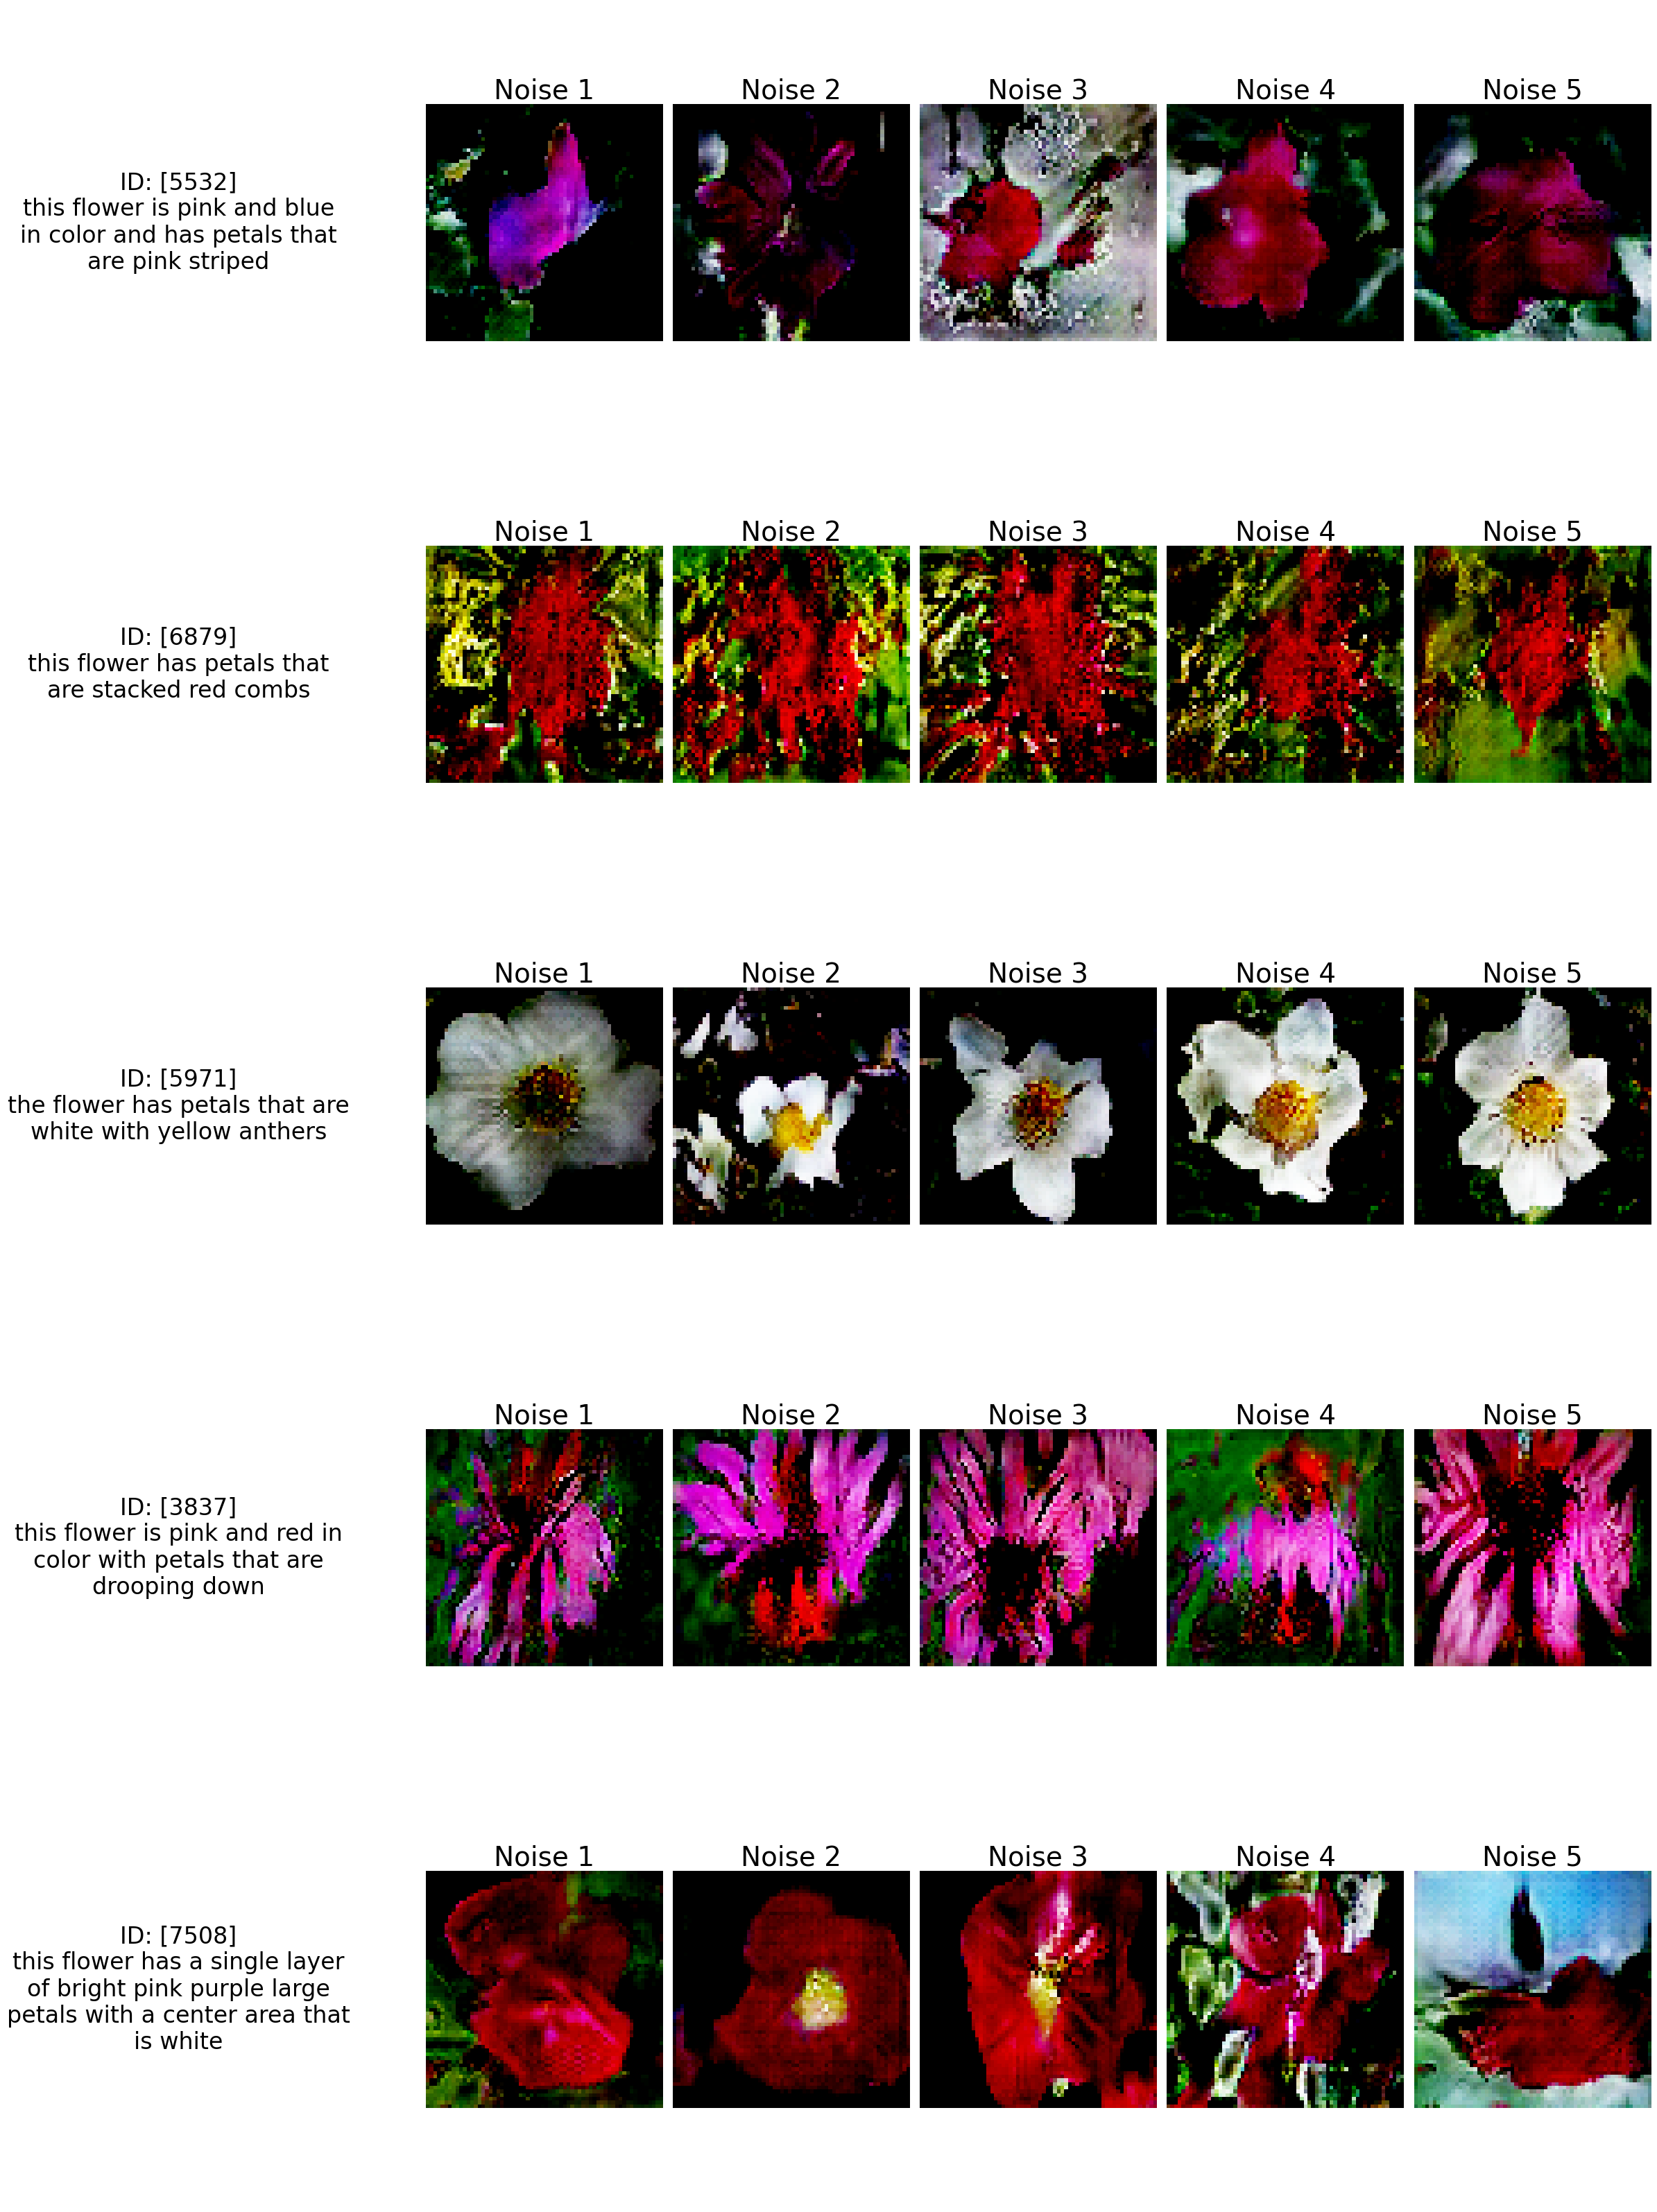

---

## **2. Model**

### **Text Encoder**
- **model**: `E2ESentenceTransformer`
- **idea**: 使用pretrain過的 `sentence-transformers/paraphrase-multilingual-mpnet-base-v2`，將文字描述轉換為特徵向量。
- **reason**: 在生成text embedding方面表現很好，能夠讓我們捕捉語句的語義，幫助模型去理解生成與描述相符合的圖片。

### **Generator**
- **model**: `Generator`
- **idea**: 接收text embedding和random noise作為輸入，通過一系列反卷積層生成 `64x64x3` 的圖片。
- **reason**: 負責從text embedding和噪音中生成圖片。為了提升效果，我們調整了模型結構，我們將文本信息與random noise進行融合，讓模型更能夠生成符合文本描述的圖片。

### **Discriminator**
- **model**: `Discriminator`
- **idea**: 使用卷積層處理text embedding和圖片，判斷圖片是否為真實圖像或生成圖像。
- **reason**: Discriminator 用來幫助 Generator 提升圖片的真實感，並能提供反饋來改善圖片品質。

### **使用 WGAN-GP**
- **reason**: 我們採用了 WGAN-GP（帶梯度懲罰的 Wasserstein GAN）來穩定對抗訓練，這可以避免model collapse並提升生成圖片的diversity。WGAN-GP 的梯度懲罰有助於穩定訓練過程，通過優化 Wasserstein 距離來衡量生成圖像與真實圖像的差異，並有效減少model collapse問題。

- **idea**:我們將text embedding與圖像結合，並通過以下方式進行處理：
  - 在 **Generator** 中，text embedding與random noise拼接，通過多層反卷積生成圖像。
  - 在 **Discriminator** 中，圖像首先經過卷積層提取特徵，然後text embedding被 reshape 並與圖像特徵拼接，進一步判斷生成圖像的真實性。

  引入梯度懲罰後，WGAN-GP 提高了生成圖片的品質與diversity。

---

## **3. experiment**

### **data augmentation**
- 增加數據的diversity，比如random_crop、random_flip、random_brightness等，提升生成圖像的diversity。

### **hyper-parameters tuning**
- 嘗試了不同的`LEARNING_RATE`、Adam optimizer中的 `beta_1` 值。
- 修改了random noise維度（`Z_DIM`）、batch size（`BATCH_SIZE`）以及 WGAN 的梯度懲罰係數（`LAMBDA`），以期達到更好的模型收斂效果和生成圖片的效果。

### **architecture tuning**
- 在 Generator 中增加了更多反卷積層，從而提升生成圖片的細節。
- 在 Discriminator 中增加了卷積層的深度，從而提升其對生成圖片的識別能力。

### **optimizer tuning**
- 除了 Adam optimizer，還嘗試了 RMSprop optimizer，對比兩者在訓練過程中的效果，選擇最適合的優化方法。

### **梯度懲罰**
- 引入梯度懲罰來穩定訓練，避免 GAN 模型出現collapse。梯度懲罰有助於讓訓練過程更穩定，並改善圖片生成的diversity和真實性。

---

## **4. Anything worth mentioning**

### **model 的pretrain**
- 使用大規模的文本語料庫pretrain Text Encoder，讓它能生更符合語意的圖。

### **check point 與恢復**
- 設置了 checkpoint，每隔幾個 epoch 保存一次模型的參數，這樣可以避免中途出錯導致訓練進度丟失得重跑。

### **生成圖片**
- 每 5 個 epoch 生成一次樣本圖片，並保存下來，方便觀察模型生成圖片的品質是否隨著訓練進行而逐步改善。

### **測試與評估**
- 每 1200 個 epoch，用testing data進行一次生成測試，讓生成的圖像除了符合training set，還能夠應對新的文本描述。

---
